# RAPID-MFA-7: Recycling

## Descriptions
This module shows how to implement material recycling in a dynamic MFA. We illustrate this with the example of steel. In this scenario outflow recycling starts in 2005 at 0% and reaches 70% by 2040. This means that a changing share of the generated outflows are 'recovered' and can be used as input for inflows. In our model this inflow of recycled material directly replaces a part of the virgin inflows. While this is not the case in our example, you may encounter situations in which the recycling flow is larger than the required inflow. In this case all virgin inflows can be replaced with recycled material and there is still recycled material left over. This 'overflow' is accounted for in a separate column, see [Section 4](#4-scenario-b).

The model takes three inputs:
- A _stocks_ time series of steel
- A _survival curve_ describing the survival/depreciation of inflow cohorts in the stocks as time goes by
- A _recycling rate_ that specifies the share of the outflows that is recycled

It produces two model outputs:
- The _recycling flows_ time series
- The _virgin inflows_ time series
- The _recycling overflow_ time series

needs to be added: circular use rate and virgin inflows and overflow explanation (# Calculate recycling flows, by multiplying the outflows with the recycling rate
# If there is a single recycling rate for the entire model, then use "recycling_rate"
# This code is written for a varying recycling rate
# If all recycled material is put into use in the same year, then mass balance: inflow = recycled material + virgin material. 
# But if there's more recycled material than inflow demand, then we would end up with negative virgin inflows.
# To address this, we create an 'overflow' column. In cases where recycling flows is larger than inflows it will only replace
# the inflows and any left over 'material' will be added to the 'overflow' column.))

### Exogenous variables
__Stocks:__ Stocks data comes from https://doi.org/10.3390/resources7010009 converted to material stocks. 

__Survival curve:__ Weibull distribution, $shape=2.4$, $scale=16.9$, e.g. using `scipy.stats.weibull_min.sf(range(0, len(input_data)), c = 2.428914875, loc = 0, scale = 16.93851375)` Data from https://doi.org/10.3390/resources7010009

### Notes
1. The input data is intended to be replaced with your own data, for example imported from an Excel or CSV file. It should be in an array-like format of any length.
2. The model is split into separate code blocks for ease of understanding. The code blocks can be merged to run as a complete model.

### Relations with other RAPID-MFA codes
- This model builds on the basic `RAPID-MFA-2: The stock driven model`.
- `RAPID-MFA-5: library of survival functions`: The code below uses the Weibull lifetime distribution. The shape and scale parameters were adapted to the literature source.

## Version, licence, and how to cite
This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 

## 1. Load libraries

In [1]:
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Define example input data

In [2]:
# %% 2. Define example input data
input_data = pd.Series([0.00000000e+00, 1.79555811e+04, 9.89352520e+06, 3.13050276e+07,
                        6.92990372e+07, 1.19345467e+08, 2.07709106e+08, 4.28015637e+08,
                        6.92482335e+08, 1.05920396e+09, 1.38068174e+09, 1.67317604e+09,
                        1.93955342e+09, 2.20988526e+09, 2.67975852e+09, 3.24683697e+09,
                        3.76840435e+09, 4.44364299e+09, 5.22389010e+09, 6.12383016e+09,
                        7.15928839e+09, 8.34696452e+09, 9.70408959e+09, 1.12478988e+10,
                        1.29949758e+10, 1.49605036e+10, 1.71573774e+10, 1.95953123e+10,
                        2.22799484e+10, 2.52121043e+10, 2.83871580e+10, 3.17947471e+10,
                        3.54187188e+10, 3.92374590e+10, 4.32244525e+10, 4.73492001e+10,
                        5.15781820e+10, 5.58760204e+10, 6.02066098e+10, 6.45341816e+10,
                        6.88242801e+10, 7.30445662e+10, 7.71654566e+10, 8.11606367e+10,
                        8.50073507e+10, 8.86865992e+10, 9.21831751e+10, 9.54856131e+10,
                        9.85860339e+10, 1.01479931e+11, 1.04165883e+11, 1.06645262e+11,
                        1.08921855e+11],
                       name = 'stocks', 
                       index = [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
                                2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
                                2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030,
                                2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041,
                                2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050])

# Parameters for the survival curve
ages = range(0, len(input_data)) 
shape = 2.428914875
scale = 16.93851375

# Define recycling rate
recycling_rate = 0.7

# Timeframe in which the recycling rate changes
recycling_timeframe_start = 2005
recycling_timeframe_end = 2040

### 2.1 Survival curve

In [3]:
# Create the survival curve
survival_curve = scipy.stats.weibull_min.sf(ages, c = shape, loc = 0, scale = scale)

### 2.2. Calculate the yearly recycling rate

In [4]:
# Interpolate the recycling rate between the start of the timeframe to the end
recycling_rate_timeseries = np.interp(input_data.index, [recycling_timeframe_start, recycling_timeframe_end], [0, recycling_rate])

## 3. Set up the MFA system

In [5]:
# %% 3. Run the stock-driven model
# %%% 3.1 Set up the MFA system
units = {'time_interval': 'year', 
         'flows': 'vehicles/year', 
         'stocks': 'vehicles'
         }

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.
time_interval = 1
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required
mfa_system_baseline = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                                         'inflows', 
                                                                         'outflows', 
                                                                         'stock_changes'])

mfa_system_baseline['stocks'] = input_data

# %%% 3.2 Create survival curves matrix
# create survival curves matrix filled with zeros
survival_curve_matrix_baseline = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curve_matrix_baseline.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]
   
# %%% 3.3 Create cohorts survival matrix
# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix_baseline = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system_baseline.loc[cohort, 'inflows'] = (
        mfa_system_baseline.loc[cohort, 'stocks'] - cohorts_survival_matrix_baseline.loc[cohort, : cohort - 1].sum()
    ) / survival_curve_matrix_baseline.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix_baseline.loc[:, cohort] = survival_curve_matrix_baseline.loc[:, cohort] * mfa_system_baseline.loc[cohort, 'inflows']
    
# %%% 3.4 Calculate the MFA system
mfa_system_baseline["stock_changes"] = np.diff(mfa_system_baseline["stocks"], prepend=0)
mfa_system_baseline["outflows"] = mfa_system_baseline["inflows"] - mfa_system_baseline["stock_changes"]

## 4. Calculate the model with a recycling rate

In [ ]:
# copy the baseline scenario for the recycling model
mfa_system_recycling = mfa_system_baseline.copy()

In [ ]:
mfa_system_recycling['recycling flows'] = mfa_system_recycling['outflows'] * recycling_rate_timeseries

In [ ]:
# Calculate the virgin inflows still required
mfa_system_recycling['virgin inflows'] = np.where(mfa_system_recycling['inflows'] - mfa_system_recycling['recycling flows'] > 0, 
                                                mfa_system_recycling['inflows'] - mfa_system_recycling['recycling flows'], 0)

# Calculate the recycling overflow 
mfa_system_recycling['recycling overflow'] = np.where(mfa_system_recycling['inflows'] - mfa_system_recycling['recycling flows'] < 0, 
                                                  abs(mfa_system_recycling['inflows'] - mfa_system_recycling['recycling flows']), 0)  

# Calculate the circular use rate
mfa_system_recycling["circular use rate"] = mfa_system_recycling.loc[:, 'recycling flows'] / mfa_system_recycling.loc[:, 'inflows']

# Caluclate the cumulative virgin inflows avoided                                        
mfa_system_recycling["virgin inflows avoided"] = mfa_system_recycling.loc[:, 'recycling flows'].cumsum() 

## 5. Compare MFA results

<Axes: title={'center': 'Cumulative virgin materials avoided'}, ylabel='kg'>

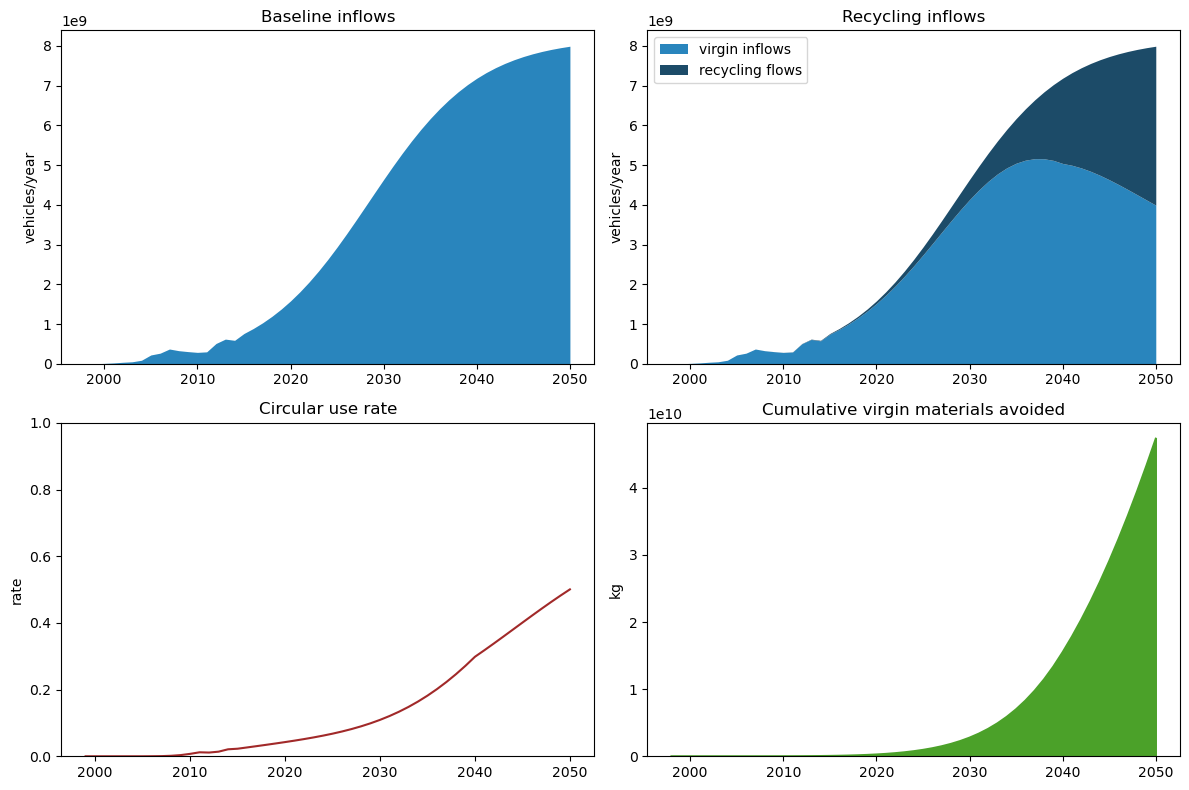

In [16]:
# visualize the inflows, outflows, and stocks results for the baseline and scenario B
results_fig, results_ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), tight_layout=True)
mfa_system_recycling.loc[:, 'inflows'].plot(ylabel=units['flows'],
                                      kind='area',
                                      color=["#2985BD"],
                                      ax=results_ax[0, 0],
                                      linewidth = 0,
                                      title = 'Baseline inflows'
                                      )

mfa_system_recycling.loc[:, ['virgin inflows', 'recycling flows']].plot(ylabel=units['flows'],
                                      kind='area',
                                      color=["#2985BD", "#1C4B68"],
                                      ax=results_ax[0, 1],
                                      linewidth = 0,
                                      title = 'Recycling inflows'
                                      )

mfa_system_recycling.loc[:, 'circular use rate'].plot(ylabel='rate', 
                                                      ax=results_ax[1, 0],
                                                      color=["#A12929FF"],
                                                      ylim=(0, 1), 
                                                      title='Circular use rate'
                                                      )

mfa_system_recycling.loc[:, 'virgin inflows avoided'].plot(ylabel='kg',
                                                           kind='area',
                                                           color=["#4BA129FF"],
                                                           ax=results_ax[1, 1],
                                                           title='Cumulative virgin materials avoided'
                                                           )